## Keras Tuner
- KerasTuner is an easy-to-use, scalable hyperparameter optimization framework that solves the pain points of hyperparameter search. Easily configure your search space with a define-by-run syntax, then leverage one of the available search algorithms to find the best hyperparameter values for your models. KerasTuner comes with Bayesian Optimization, Hyperband, and Random Search algorithms built-in, and is also designed to be easy for researchers to extend in order to experiment with new search algorithms.

--------------------

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score
import pickle

In [2]:
df = pd.read_csv("../../../datasets/auto-mpg.csv")
df.shape

(398, 9)

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.tail()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


In [5]:
df.sample(5)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
288,18.2,8,318.0,135,3830,15.2,79,1,dodge st. regis
300,23.9,8,260.0,90,3420,22.2,79,1,oldsmobile cutlass salon brougham
204,32.0,4,85.0,70,1990,17.0,76,3,datsun b-210
363,22.4,6,231.0,110,3415,15.8,81,1,buick century
82,23.0,4,120.0,97,2506,14.5,72,3,toyouta corona mark ii (sw)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [7]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=["car name", "horsepower"], axis=1, inplace=True)

In [10]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Keras Tuner - (Hyper Parameter Tuning)

- 1\) how to select appropriate optimizer
- 2\) number of nodes in layer
- 3\) how to select number of layers
- 4\) all in one model

In [13]:
# pip install keras-tuner
# pip install tensorboard

In [14]:
import keras_tuner as kt

In [15]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.regularizers import l1, l2, l1_l2

# def build_model(hp):
#     model = Sequential()

#     # Tune number of layers
#     num_layers = hp.Int("num_layers", min_value=1, max_value=10)

#     for i in range(num_layers):

#         units = hp.Int(f'units_{i}', min_value=8, max_value=256, step=8)

#         activation = hp.Choice(
#             f'activation_{i}',
#             values=["relu", "tanh", "elu", "selu"]  # removed sigmoid (not ideal for regression)
#         )

#         # Regularization
#         reg_choice = hp.Choice(f'reg_{i}', ["none", "l1", "l2", "l1_l2"])
#         if reg_choice == "l1":
#             reg = l1(hp.Float(f"l1_{i}", 1e-6, 1e-2, sampling="log"))
#         elif reg_choice == "l2":
#             reg = l2(hp.Float(f"l2_{i}", 1e-6, 1e-2, sampling="log"))
#         elif reg_choice == "l1_l2":
#             reg = l1_l2(
#                 l1=hp.Float(f"l1l2_l1_{i}", 1e-6, 1e-2, sampling="log"),
#                 l2=hp.Float(f"l1l2_l2_{i}", 1e-6, 1e-2, sampling="log")
#             )
#         else:
#             reg = None

#         # First layer
#         if i == 0:
#             model.add(Dense(units,
#                             activation=activation,
#                             kernel_regularizer=reg,
#                             input_dim=X_train.shape[1]))
#         else:
#             model.add(Dense(units,
#                             activation=activation,
#                             kernel_regularizer=reg))

#         # BatchNorm
#         if hp.Boolean(f'batch_norm_{i}'):
#             model.add(BatchNormalization())

#         # Dropout
#         model.add(Dropout(
#             hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)
#         ))

#     #  Output layer for regression (IMPORTANT CHANGE)
#     model.add(Dense(1, activation="linear"))

#     # Optimizer
#     optimizer_choice = hp.Choice("optimizer", ["adam", "rmsprop", "sgd", "nadam"])
#     learning_rate = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

#     if optimizer_choice == "adam":
#         optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#     elif optimizer_choice == "rmsprop":
#         optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
#     elif optimizer_choice == "sgd":
#         optimizer = tf.keras.optimizers.SGD(
#             learning_rate=learning_rate,
#             momentum=hp.Float("momentum", 0.0, 0.9, step=0.1)
#         )
#     elif optimizer_choice == "nadam":
#         optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

#     # ✅ Regression losses
#     loss = hp.Choice("loss", ["mse", "mae", "huber"])

#     model.compile(
#         optimizer=optimizer,
#         loss=loss,
#         metrics=[
#             "mae",
#             tf.keras.metrics.RootMeanSquaredError(name="rmse")
#         ]
#     )

#     return model

In [16]:
def build_model(hp):
    model = Sequential()


    counter = 0
    for i in range(hp.Int("num_layers", min_value=3, max_value=10)):
        if counter == 0:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=128, step=8),
                    activation = hp.Choice("activation" + str(i), values=["relu", "elu", "selu"]),
                    input_dim = X_train.shape[1]
                ))

            model.add(
                Dropout(
                    hp.Choice("dropout" + str(i), values=[0.1,0.2,0.3,0.4,0.5])
                )
            )
        else:
            model.add(
                Dense(
                    hp.Int("units" + str(i), min_value=8, max_value=128, step=8),
                    activation = hp.Choice("activation" + str(i), values=["relu", "elu", "selu"])
                ))

            model.add(
                Dropout(
                    hp.Choice("dropout" + str(i), values=[0.1,0.2,0.3,0.4,0.5])
                )
            )
            
        counter += 1

    model.add(Dense(1, activation="linear"))

    model.compile(optimizer=hp.Choice("optimizer", values=["rmsprop", "adam", "sgd", "nadam", "adadelta"]),
                  loss=hp.Choice("loss", ["mse", "mae", "huber"]),
                  metrics=["mae"])
    

    return model

In [17]:
tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_mae", direction="min"),  # better for regression
    max_trials=30,   # increase search space
    executions_per_trial=2,  # reduce randomness
    directory="mydir",
    project_name="all_tuning_regression"
)

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuner.search(
    X_train,
    y_train,
    epochs=30,   
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    batch_size=kt.engine.hyperparameters.HyperParameters().Choice(
        "batch_size", [16, 32, 64, 128]
    )
)

Trial 30 Complete [00h 00m 09s]
val_mae: 0.37290653586387634

Best val_mae So Far: 0.35066017508506775
Total elapsed time: 00h 04m 49s


In [25]:
tuner.get_best_hyperparameters()[0].values

{'num_layers': 9,
 'units0': 80,
 'activation0': 'elu',
 'dropout0': 0.2,
 'units1': 80,
 'activation1': 'elu',
 'dropout1': 0.2,
 'units2': 64,
 'activation2': 'selu',
 'dropout2': 0.1,
 'optimizer': 'rmsprop',
 'loss': 'mse',
 'units3': 104,
 'activation3': 'relu',
 'dropout3': 0.3,
 'units4': 16,
 'activation4': 'selu',
 'dropout4': 0.1,
 'units5': 72,
 'activation5': 'elu',
 'dropout5': 0.3,
 'units6': 88,
 'activation6': 'selu',
 'dropout6': 0.1,
 'units7': 56,
 'activation7': 'relu',
 'dropout7': 0.2,
 'units8': 128,
 'activation8': 'selu',
 'dropout8': 0.3,
 'units9': 64,
 'activation9': 'relu',
 'dropout9': 0.5}

In [26]:
model = tuner.get_best_models(num_models=1)[0]

C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\bhushan.chitte\AppData\Roaming\Python\Python310\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [27]:
history = model.fit(X_train, y_train, epochs=100, initial_epoch=30, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 31/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.4703 - mae: 0.4914 - val_loss: 0.3241 - val_mae: 0.3546
Epoch 32/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4604 - mae: 0.4808 - val_loss: 0.3506 - val_mae: 0.3623
Epoch 33/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4135 - mae: 0.4597 - val_loss: 0.3245 - val_mae: 0.3665
Epoch 34/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4273 - mae: 0.4627 - val_loss: 0.3439 - val_mae: 0.3709
Epoch 35/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4138 - mae: 0.4655 - val_loss: 0.3485 - val_mae: 0.4015
Epoch 36/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4689 - mae: 0.4806 - val_loss: 0.3317 - val_mae: 0.3789
Epoch 37/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4086 - mae: 0.4533 - val_loss: 0.3150 - val_mae: 0.4005
Epoch 38/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4333 - mae: 0.4695 - val_loss: 0.3228 - val_mae: 0.3836
Epoch 39/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - l

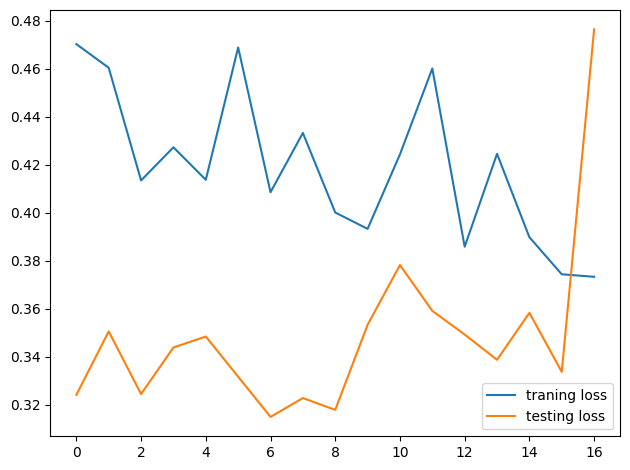

In [28]:
plt.Figure(figsize=(12,8))

sns.lineplot(history.history["loss"], label="traning loss")
sns.lineplot(history.history["val_loss"], label="testing loss")


plt.legend()
plt.tight_layout()
plt.show()

In [29]:
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


0.4247463345527649